# PyTorch Lightning fine-tuning template

by Andrés Muñoz-Jaramillo

This notebook is meant to act as a template to train and use a surya model to implement DS application.

It focuses on the concept of defining a modified Surya model, loading its weigths, and using a PyTorch lightning training loop to train it

This notebook assumes familiarity with the concepts of datasets and dataloaders contained in the **_0_dataset_dataloader_template.ipynb_**

It doesn't require having seen the baselines template, but they are meant to complement each other.  **_In fact they are on purpose almost identical!!!_**

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.   

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. It is what lets training.deterministic work without a
# cuBLAS warning on every run. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
from torch.utils.data import DataLoader

import torch
import yaml

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger, WandbLogger

# Append base path.  May need to be modified if the folder structure changes.
# It gives the notebook access to the wokshop_infrastructure folder.
sys.path.append("../../")
 
# Append Surya path. May need to be modified if the folder structure changes.
# It gives the notebook access to surya's release code.

from workshop_infrastructure.utils import build_scalers  # Data scaling utilities for Surya stacks
from workshop_infrastructure.utils import apply_peft_lora
torch.set_float32_matmul_precision('medium')



## Load configuration

Surya was designed to read a configuration file that defines many aspects of the model
including the data it uses we use this config file to set default values that do not
need to be modified, but also to define values specific to our downstream application

In [3]:
# The config is the single source of truth. load_sep_psp_ds_config() parses it into a typed
# object, exactly as the training script 3_finetune_template_1D.py does, so the same YAML
# behaves identically here and in production. Notebook 0 walks through what it contains.
from downstream_apps.sep_pred_psp.configs import load_sep_psp_ds_config

cfg = load_sep_psp_ds_config("./configs/config_script.yaml")
print(f"Loaded config for job: {cfg.job_id}")


Loaded config for job: sep_pred_psp


## Download assets

The config says where the assets belong, so it is loaded first. `ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.


In [4]:
# One implementation, shared by the notebooks, the training script and the
# download_*.sh wrappers: workshop_infrastructure/assets.py.
# Fine-tuning needs the pretrained backbone as well (~1.8 GB).
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=["scalers", "weights"])

# Now that scalers.yaml is guaranteed to be on disk, load it. build_scalers()
# accepts the resolved path directly.
scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")


Loaded scalers for 13 channels.


### Typed configuration, and how to extend it for your own task

`load_sep_psp_ds_config()` reads `configs/config_script.yaml` and returns a typed `TrainingConfig`.
This notebook and `3_finetune_template_1D.py` call the same function on the same file, so
there is no notebook-versus-script divergence to reason about.

| YAML section | Access in Python | Dataclass |
|---|---|---|
| `data:` | `cfg.data.*` | `SepPspDSDataConfig` (this app) |
| `model:` | `cfg.model.*` | `ModelConfig` |
| `model.lora_config:` | `cfg.model.lora_config.*` | `LoraAdapterConfig` |
| `model.time_embedding:` | `cfg.model.time_embedding.*` | `TimeEmbeddingConfig` |
| `training:` | `cfg.learning_rate`, `cfg.batch_size`, … | `TrainingConfig` (flat) |
| `output:` | `cfg.output.*` | `OutputConfig` |
| `logging:` | `cfg.wandb_project`, `cfg.wandb_entity` | `TrainingConfig` (flat) |

**Everything except `SepPspDSDataConfig` lives in `workshop_infrastructure/configs.py`** and is
shared by every downstream app. When you fork the template you do not copy that file. You
subclass `DataConfig` with your task's fields and bind `load_config` to it — the whole of
`downstream_apps/sep_pred_psp/configs.py` is:

```python
@dataclass
class SepPspDSDataConfig(DataConfig):
    sep_psp_index_path: str = ""
    ds_time_column: str = "start_time"
    ds_time_tolerance: str = "4d"
    ds_match_direction: str = "forward"
    PATH_FIELDS = DataConfig.PATH_FIELDS + ("sep_psp_index_path",)   # resolve it like a path

load_sep_psp_ds_config = partial(load_config, data_cls=SepPspDSDataConfig)
```

Unknown keys are rejected rather than silently dropped: if you add a key to the YAML before
adding the field, you get an error naming the key and listing the valid ones.


**_Important — what limits this dataset:_** the scarce class is the **active** one. At the config's thresholds (label > `active_above`, < `quiet_below`, band between dropped), one row per Surya frame, the splits hold **762 active / 8,320 quiet** (train 2020/21/23/24), **12 active / 981 quiet** (val 2022 Jan–Jul) and **105 active / 1,641 quiet** (test 2022 Aug–Dec). A balanced draw therefore caps at about **1,524 train** samples but only **24 val** samples — 2022 was a quiet year. `sample_balanced()` warns whenever a split cannot supply what was asked for, so read that warning rather than assuming the draw is the size you requested.


In [5]:
from downstream_apps.sep_pred_psp.datasets.template_dataset import SepPspDSDataset

In [6]:
# build_helio_dataloaders() constructs the train and validation datasets and wraps them
# in DataLoaders. It fills in every generic argument (channels, temporal sampling, S3
# access, worker settings) from the config — see notebook 0 for what that block looks
# like written out. Only the SEP/PSP-specific arguments are passed here, which is exactly
# the list you replace when you fork the template.
#
# It also handles two details that are easy to get wrong by hand: the validation set gets
# phase="val" (no random channel masking or flips), and only the training loader shuffles.
from workshop_infrastructure.datasets.builders import build_helio_dataloaders
from downstream_apps.sep_pred_psp.datasets.label_transform import build_log_standardizer

# >>> The knob for a learning curve. Change ONLY this between runs. <<<
n_train_samples = 50          # try 50, 100, 200, 500
n_val_samples = cfg.data.val_samples   # pinned in the YAML (50) — do not sweep this

label_transform = build_log_standardizer(
    cfg.data.sep_psp_index_path, cfg.data.train_data_path, column=cfg.data.label_column
)
print(f"[label] {label_transform}")

train_data_loader, val_data_loader = build_helio_dataloaders(
    cfg,
    SepPspDSDataset,
    scalers=scalers,
    num_workers=4,          # fewer workers than the script: notebooks start faster
    #### Downstream (DS) specific parameters
    return_surya_stack=True,
    # Per-split sizes: the training set grows, the validation set never moves.
    train_kwargs={"max_number_of_samples": n_train_samples},
    val_kwargs={"max_number_of_samples": n_val_samples},
    # A frame is active above cfg.data.active_above and quiet below cfg.data.quiet_below,
    # both in the label column's own units; frames in between are dropped.
    active_above=cfg.data.active_above,
    quiet_below=cfg.data.quiet_below,
    # log10 + z-score of cfg.data.label_column, fitted on the TRAINING split only and
    # shared by both splits: raw Jlinlin spans ~6 decades, so an MSE trained on it is
    # decided by a handful of large events. One transform for every rung of the learning
    # curve keeps every run's val_loss on the same scale.
    label_column=cfg.data.label_column,
    label_transform=label_transform,
    ds_sep_psp_index_path=cfg.data.sep_psp_index_path,
    ds_time_column=cfg.data.ds_time_column,
    ds_time_tolerance=cfg.data.ds_time_tolerance,
    ds_match_direction=cfg.data.ds_match_direction,
    ds_non_event_buffer=cfg.data.non_event_buffer,
    sample_seed=cfg.seed,
)

batch_size = cfg.batch_size
for name, loader in [("train", train_data_loader), ("val", val_data_loader)]:
    df = loader.dataset.df_valid_indices
    col = cfg.data.label_column
    print(f"{name:5s}: {len(loader.dataset):4d} samples | "
          f"{int(df['is_event'].sum()):3d} active / {int((df['is_event'] == 0).sum()):3d} quiet | "
          f"{col} median {df.loc[df['is_event'] == 1, col].median():.3g} (active) "
          f"vs {df.loc[df['is_event'] == 0, col].median():.3g} (quiet)")
print(f"batch_size: {batch_size}")


[label] log10(Jlinlin_raw) z-scored with mean=-1.2908, std=0.8257 (from 92,778 training-split catalog rows)


train:   50 samples |  25 active /  25 quiet | Jlinlin_raw median 3.14 (active) vs 0.0187 (quiet)
val  :   24 samples |  12 active /  12 quiet | Jlinlin_raw median 1.41 (active) vs 0.015 (quiet)
batch_size: 2


Training and validation get separate datasets and dataloaders. They differ only in the index they read and in `phase`: `phase="val"` turns off the random channel masking and vertical flips used for training augmentation.

The loaders use `multiprocessing_context="spawn"` — the dataset holds an S3 client that does not survive `fork`, and spawn also avoids lockups in shared environments.


In [ ]:
# Inspect a single batch to confirm shapes before building the model.
batch = next(iter(train_data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})


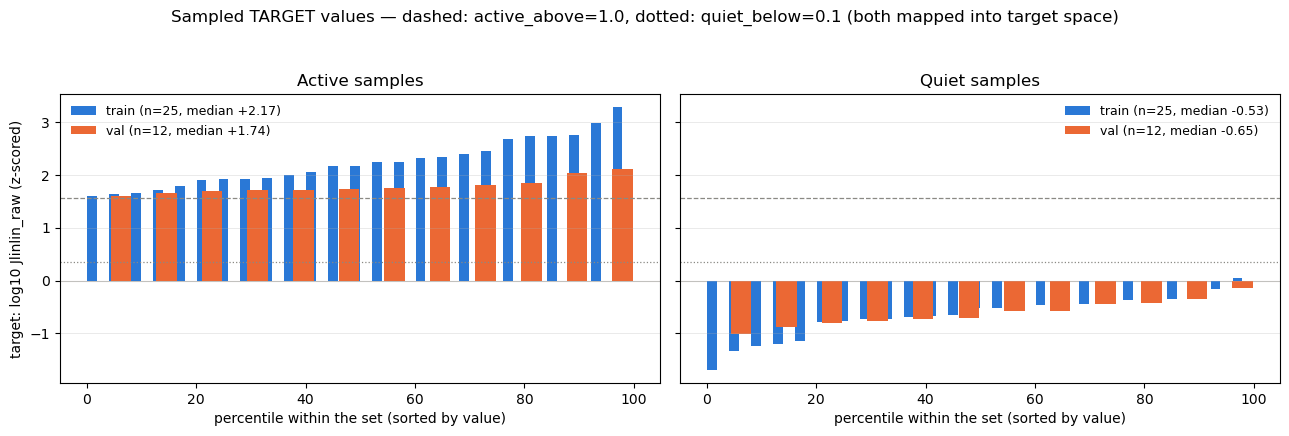

In [7]:
# TARGET values of the drawn samples: active (left) vs quiet (right), train vs val.
# Reads the sampler's own table, so it needs no batch and no GPU. y is the target the model
# is trained on -- normalized_intensity, i.e. log10(label) z-scored -- so it is directly
# comparable with the predictions plotted at the end of the run. The raw label is in the
# cfg.data.label_column column of the same table if you want it in physical units.
# x is the percentile rank within each set, so the training and validation sets are
# comparable side by side despite their different sizes.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sets = {"train": train_data_loader.dataset.df_valid_indices,
        "val":   val_data_loader.dataset.df_valid_indices}
colors = {"train": "#2a78d6", "val": "#eb6834"}
# The two class thresholds, mapped into target space so they can be drawn on this axis.
thresholds = label_transform(pd.Series([cfg.data.active_above, cfg.data.quiet_below]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (flag, name) in zip(axes, [(1, "Active"), (0, "Quiet")]):
    for split, df in sets.items():
        v = np.sort(df.loc[df["is_event"] == flag, "normalized_intensity"].to_numpy(float))
        if len(v) == 0:
            continue
        # Bar centres at each sample's percentile rank; width = one such step, halved so
        # the two series sit side by side instead of hiding one another.
        step = 100 / len(v)
        x = (np.arange(len(v)) + 0.5) * step
        off = -0.25 if split == "train" else 0.25
        ax.bar(x + off * step, v, width=0.45 * step, color=colors[split],
               label=f"{split} (n={len(v)}, median {np.median(v):+.2f})")
    for level, style in zip(thresholds, ["--", ":"]):
        ax.axhline(level, color="#8a8984", linestyle=style, linewidth=0.9)
    ax.axhline(0, color="#c9c8c3", linewidth=0.8, zorder=0)
    ax.set_title(f"{name} samples", fontsize=12)
    ax.set_xlabel("percentile within the set (sorted by value)")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis="y", alpha=0.3, linewidth=0.6)
axes[0].set_ylabel("target: log10 " + cfg.data.label_column + " (z-scored)")
fig.suptitle(f"Sampled TARGET values — dashed: active_above={cfg.data.active_above}, "
             f"dotted: quiet_below={cfg.data.quiet_below} (both mapped into target space)",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


## Initialize the HelioSpectformer model

This is the main difference beteween the notebook that trains the simple model and the one that fine-tunes Surya.  

In the case of the finetuning exercise one of the main differences between DS applications is the dimensionality of the output.  In this notebook we use a modified HelioSpectformer that projects into a 1D space. 

**_IMPORTANT: If your DS application is 2D you need to use the HelioSpectformer2D_**

In [8]:
from workshop_infrastructure.models.finetune_models import HelioSpectformer1D

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Now the config file really comes into bear. The Spectformer has a metric ton of hyperparameters

In [9]:
# HelioSpectformer1D has a long list of architecture arguments, and all of them come
# straight from the model: section of the config. from_config() does that mapping, so the
# backbone can never drift out of sync with the checkpoint it is about to load.
#
# Arguments that are not part of ModelConfig (dtype, and anything from the training:
# section) are passed as explicit overrides.
model = HelioSpectformer1D.from_config(
    cfg.model,
    num_outputs=1,
    dtype=cfg.dtype,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
)


## Load model weights

Here we load the pre-trained checkpoint and load the weights.  The exercise of loading follows the idea of us as many of the weights as possible.  This is accomplished through the filtered_checkpoint_state.   It checks to see if the pretrained model's layers match those of your finetuning architecture.   It also checks that all your dimensions across layers check out.   If something does not work those paramameters are left in their random initialization. 

In [10]:
# The checkpoint was saved from HelioSpectFormer directly, so its keys are flat
# (e.g. "embedding.proj.weight"), while the fine-tuning model nests the backbone under
# "backbone.*". load_pretrained_weights() tries both spellings and reports how many
# tensors matched — a low count means the architecture does not match the checkpoint.
from workshop_infrastructure.utils import load_pretrained_weights

load_pretrained_weights(model, cfg.model.pretrained_path)


Loading pretrained weights from /home/jovyan/surya_workshop_fork/downstream_apps/sep_pred_psp/assets/surya.366m.v1.pt.


Loaded 156 / 159 pretrained weights.


## To LoRA or not to Lora

This cell gives you two options.  On the one hand we have the classic freezing of the backbone (the initial layers of the model).   On the other hand we have the use of a LoRA.

LoRas have been a remarkable addition to our arsenal of models.   They have the advantage of keeping pretty much the entire model intact and only add broad modifications to weights as needed.

**What actually trains.** In the LoRA regime it is the adapters *and* the whole fine-tuning head. That second part is easy to get wrong: PEFT freezes every parameter it does not recognise as an adapter, so unless the head is explicitly handed to it as `modules_to_save`, the adapters end up fitting a **frozen, randomly initialised readout** — and the loss still goes down, so the training curve looks perfectly healthy. `apply_peft_lora()` avoids this by discovering every `head_*` attribute on the model and marking it trainable. If you add your own head layer, give it a `head_` prefix or it will be silently frozen (the helper checks this at startup and tells you what to rename).

**Where the adapters go.** `fc1`/`fc2` in all ten blocks, plus `attn.qkv` and `attn.proj` in the eight attention blocks. The spectral `complex_weight`, `attn.to_dynamic_projection`, and the patch embedding are never adapted.

Surya fuses query, key and value into a single `nn.Linear(1280, 3840)`, so one adapter covers all three at once: they share the `8×1280` matrix `A` and each gets its own `1280×8` slice of `B`. Their combined rank is at most 8 — which is *not* the same as giving q, k and v three independent rank-8 adapters.

Run the cell below and check the printout: the LoRA regime should report **3,157,761** trainable parameters (1,515,520 of adapters + 1,642,241 of head), and the linear probe **1,642,241**.

In [11]:
# Three fine-tuning regimes, all selected from the model: section of the config:
#
#   use_lora: true                          -> LoRA adapters + the whole head (default)
#   use_lora: false, freeze_backbone: true  -> linear probe: only the head trains
#   use_lora: false, freeze_backbone: false -> full fine-tuning of all 366M parameters
#
# freeze_backbone is ignored when use_lora is true: PEFT freezes everything, then
# re-enables the adapters and every head_* module.
#
# 3_finetune_template_1D.py applies exactly this logic in build_model().
if cfg.model.freeze_backbone:
    for name, param in model.named_parameters():
        if name.startswith("backbone."):
            param.requires_grad = False

if cfg.model.use_lora:
    # Prints the adapted modules and the trainable head modules it discovered.
    model = apply_peft_lora(model, cfg.model.lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['fc1', 'fc2', 'attn.qkv', 'attn.proj']


[LoRA] Adapted modules (36):
[LoRA]   backbone.backbone.blocks_attention.0.attn.proj
[LoRA]   backbone.backbone.blocks_attention.0.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.0.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.1.attn.proj
[LoRA]   backbone.backbone.blocks_attention.1.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.1.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.2.attn.proj
[LoRA]   backbone.backbone.blocks_attention.2.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.2.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.3.attn.proj
[LoRA]   backbone.backbone.blocks_attention.3.attn.qkv
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc1
[LoRA]   backbone.backbone.blocks_attention.3.mlp.fc2
[LoRA]   backbone.backbone.blocks_attention.4.attn.proj
[LoRA]   backbone.backbone.blocks_atten

We can now test that this model manipulates a batch as expected and returns an estimate of SEP intensity (Jlinlin) as we did for the simple baseline.

We pass the input stack 'ts' to the model to transform it into our regression output.   Note that since this model was trained for a different task, it's likely it won't perform very well.  As with the simple baseline, this only acts as a test that our model forward doesn't have dimension problems.

Dimension problemns are the dominant source of error in this kind of work.

Note that our output has now the size of our batch.

In [ ]:
batch = next(iter(train_data_loader))
output = model.forward(batch)  # Get rid of singleton dimension
output

## Define your metrics

Metrics are a very important part of training AI models.   They provide your models with the quantitification of error, which in turn shifts the weights towards better pefrorming models.  They also provide a way for you to monitor performance, identify overfitting, and quantify value added. 

We now initialize the metrics class which allows you to control what metrics do you want to use as "loss" (i.e. the metrics that backpropagate through your model) and which ones for monitoring performance.  As with other components, this takes the form of a loaded module that can be later use in a training script

In [12]:
from downstream_apps.sep_pred_psp.metrics.template_metrics import SepPspMetrics

In [13]:
train_loss_metrics = SepPspMetrics("train_loss")
# val_loss is the quantity logged as "val_loss" and used to pick the best checkpoint.
# It defaults to the same MSE as train_loss — override SepPspMetrics.val_loss to change it.
val_loss_metrics = SepPspMetrics("val_loss")
train_evaluation_metrics = SepPspMetrics("train_metrics")
# Reported only: val_metrics do NOT influence checkpoint selection.
validation_evaluation_metrics = SepPspMetrics("val_metrics")

Now they can be evaluated in our model's output and our ground truth.   First the loss that actually will backpropagate, in this case Mean Squared Errror

In [14]:
train_loss_metrics(output, batch["forecast"])

NameError: name 'output' is not defined

Then a training evaluation that will not backpropagate and inform our model, but that we can keep an eye on. Note that reporting lots of metrics during training will slow the training process.  I'm including it her as an example, but oftentimes is better to put the diagnostics only in the validation evaluation metrics.

Here we are caclulating the Root Relative Squared Error https://lightning.ai/docs/torchmetrics/stable/regression/rse.html 

A value below one means the prediction is better than predicting the average.  It is unlikely that this metric will be lower than one with a randomly initialized model

In [ ]:
train_evaluation_metrics(output, batch["forecast"])

In the validation evaluation metrics we report both MSE and RRSE

In [ ]:
validation_evaluation_metrics(output, batch["forecast"])

## Define your PyTorch ligthning module

In this workshop we will use PyTorch lightning to train our models.  PyTorch lighting reduces the amount of code required to implement a training loop in comparison to PyTorch (at the expense of control and versatility).  

Opening the SepPspLightningModule shows a simple Lightning model implementation.  It consists of:

- An initialization of the class (metrics, model, and learning rate).
- The forward code that runs evaluation of the model.
- Training and validation steps.
- Configuration of optimizers.

**_Note that it is the same Lightning module we used for the baseline!!_**

In [15]:
from downstream_apps.sep_pred_psp.lightning_modules.pl_simple_baseline import SepPspLightningModule

## Set your global seeds

Since training AI models generally uses stochastic gradient descent, it is a good idea to fix your random seeds so that your training exercise is reproducible.    

In [16]:
L.seed_everything(42, workers=True)

Seed set to 42


42

## Intialize Lightning module

Now we properly initalize the Lightning module to enable training, including passing the dictionary of metrics

In [17]:
metrics = {
    'train_loss': train_loss_metrics,
    'val_loss': val_loss_metrics,
    'train_metrics': train_evaluation_metrics,
    'val_metrics': validation_evaluation_metrics,
}

lit_model = SepPspLightningModule(model, metrics, lr=cfg.learning_rate, batch_size=batch_size)


## Logging

In order to properly compare experiments against each other, it is very useful to log evaluation metrics in a place where they can be compared against other training runs.  In this workshop we will use Weights and Biases (WandB). 

The first time you run WandB in a machine it will ask you to login to WandB.  You should have received an invitation to our project.  In order to login you must:

- Select option 2 (existing account).   In VScode the dialog opens a box at the top of your screen.
- Click on get API Key (this will open a browser).
- Generate API Key.
- Paste it in the dialog box at the top of your VSCode

In [18]:
project_name = cfg.wandb_project
max_epochs = 20

# Run name encodes the setup: s = train samples, e = epochs, b = batch size
# (e.g. finetune_s20_e20_b2).
run_name = f"finetune_s{len(train_data_loader.dataset)}_e{max_epochs}_b{batch_size}"
print(f"Run name: {run_name}")

wandb_logger = WandbLogger(
    entity=cfg.wandb_entity,  # set wandb_entity in the config; null = personal account
    project=project_name,
    name=run_name,
    log_model=False,
    save_dir="./wandb/wandb_tmp",
)

csv_logger = CSVLogger("runs", name=project_name)


Run name: finetune_s50_e20_b2


## Initialize trainer

With the loggers done, now the trainer needs to be defined.  The trainer defines several properties of your training run. Here we define:

- The max number of epochs (one epoch represents your model seeing your entire training dataset).
- Define where the training run will take place (auto uses the GPU if possible, if not, CPU).
- The loggers.
- The callbacks (here we save the model with the lowest validation loss).
- Logging frequency (because we are working with a small dataset it needs to be small).


**Note that in this notebook we also set a mixed precision to reduce the model's footprint in memory.**

### Validation predictions and the best-epoch figure

`ValidationPredictionLogger` does two things:

* **Every epoch**, it writes one row per validation sample to `runs/<run_name>/val_predictions/val_predictions.csv` — epoch, Surya frame, `is_event`, true label and prediction. That file is yours to re-plot from afterwards, and it is written whether or not WandB is on.
* **For the best epoch only** (the one that minimized `val_loss` — the same epoch `ModelCheckpoint` keeps), it renders a two-panel histogram: 25 non-event samples on the left, 25 event samples on the right, true vs. predicted in each, with RMSE per panel and overall printed in the image. It is saved as `val_predictions_best.png` and logged to WandB under `val_prediction_histograms`.

The figure is rendered once at the end of `fit`, so each run logs exactly one image and it always matches the saved checkpoint. Bins are shared across both panels and spaced in log10 (the label spans ~5 decades), so the two panels are directly comparable.


In [19]:
# max_epochs is set in the logging cell above so the run name can include it.
from downstream_apps.sep_pred_psp.lightning_modules.val_prediction_logger import (
    ValidationPredictionLogger,
)

# Saves every epoch's validation predictions, and logs the BEST epoch's per-sample
# true-vs-predicted bars (non-event | event, with RMSE) to WandB. monitor must match ModelCheckpoint's,
# or the figure would describe a different epoch from the one whose weights were kept.
val_predictions_cb = ValidationPredictionLogger(
    output_dir=f"runs/{run_name}/val_predictions",
    monitor="val_loss",
    mode="min",
    # The target is log10-z-scored: already log space, legitimately negative.
    label_name="log10 Jlinlin (z-scored)",
    log_y=False,
)

# -------------------------------------------------------------------------
# Trainer
# -------------------------------------------------------------------------
trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    precision="bf16-mixed", 
    logger=[wandb_logger, csv_logger],
    callbacks=[
        ModelCheckpoint(
            monitor="val_loss",
            mode="min",
            save_top_k=1,
        ),
        val_predictions_cb,
    ],
    log_every_n_steps=2,
)


Using bfloat16 Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

Finally we fit the model.  We pass the Lighting module, and our dataloaders.

In [20]:
trainer.fit(lit_model, train_data_loader, val_data_loader)

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


wandb: Currently logged in as: skasapis (surya-ws2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type      | Params | Mode  | FLOPs
----------------------------------------------------
0 | model | PeftModel | 362 M  | train | 0    
----------------------------------------------------
3.2 M     Trainable params
359 M     Non-trainable params
362 M     Total params
1,449.868 Total estimated model params size (MB)
540       Modules in train mode
0         Modules in eval mode
0         Total Flops


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


[VAL] Best-epoch histogram: runs/finetune_s50_e20_b2/val_predictions/val_predictions_best.png
[VAL] Per-epoch predictions: runs/finetune_s50_e20_b2/val_predictions/val_predictions.csv


## Conclusion

With this we have now integrated our dataset, dataloaders, metrics, and DS into an end-2-end training loop and we are ready to experiment!